# Modelling

Initial setup for modelling with randomforest, histgradientboosting and logisticregression and features. Currently the randomforest part of the notebook uses some memory, so 48GB of RAM is a good start.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [1]:
import geopandas as gpd
import pandas as pd
import rasterio as rio
import numpy as np
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from pathlib import Path


import xdem
import geoutils as gu
from joblib import dump
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV

import json

import subkart

## Terrain features

In [ ]:
layer = "Dybdekurve"
depth_mr = Path(
    "../geonorge/Basisdata_15_More_og_Romsdal_25833_Dybdedata_GML.gml"
)
output_path = Path(f"../geonorge/Basisdata_15_More_og_Romsdal_25833_Dybdedata_{layer}.geo.parquet")
#subkart.utils.to_geoparquet(depth_mr, layer, output_path)

depth_vl = Path(
    "../geonorge/Basisdata_46_Vestland_25833_Dybdedata_GML.gml"
)
output_path = Path(f"../geonorge/Basisdata_46_Vestland_25833_Dybdedata_{layer}.geo.parquet")
#subkart.utils.to_geoparquet(depth_vl, layer, output_path)
#https://kartkatalog.geonorge.no/metadata/sjoekart-dybdedata/2751aacf-5472-4850-a208-3532a51c529a?search=basisdata%20sj%C3%B8
# https://kartkatalog.geonorge.no/metadata/dybdedata-terrengmodeller-dtm-wcs/8896c751-f3e0-4e4c-86e2-7579cea1f111

Written GeoParquet to ../geonorge/Basisdata_15_More_og_Romsdal_25833_Dybdedata_Dybdekurve.geo.parquet
Written GeoParquet to ../geonorge/Basisdata_46_Vestland_25833_Dybdedata_Dybdekurve.geo.parquet


In [ ]:
gdf = gpd.read_file(depth_mr, layer='Dybdeareal')
gdf.explore(column="maksimumsdybde", cmap="viridis", legend=True, figsize=(8, 8), edgecolor="none").save("maksimumsdybde_map.html")

In [10]:
gdf

,gml_id,lokalId,navnerom,versjonId,oppdateringsdato,datauttaksdato,minimumsdybde,maksimumsdybde,førsteDatafangstdato,geometry
0,idd9254bce-2c6a-4123-8d59-bb6b657d5771,4b73a8c9-3fac-40d5-90af-fbadf8f064c0,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,2008-11-20T00:00:00,2026-02-09T09:51:55,0.5,10.0,None,"POLYGON ((143771.423 7042552.436, 143765.714 7..."
1,ided0a88f0-f81f-4d99-b4a1-7243328c32e6,e2269b27-9443-4573-bae3-4be9cf949649,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,2008-07-03T00:00:00,2026-02-09T10:02:09,0.5,10.0,2000-03-03T00:00:00,"POLYGON ((145375.886 7044301.526, 145371.308 7..."
2,id8ca8bef1-6567-4fe8-bd78-c8e870c16b4e,cecca6d5-4680-427a-b1fe-6bc1a4fcfef0,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,2008-11-03T00:00:00,2026-02-09T10:02:25,10.0,20.0,None,"POLYGON ((145662.921 7039629.802, 145655.413 7..."
3,idd3804f99-f0cb-4b5c-adf3-012a7e10f579,4b55d053-b615-441c-b632-3d917a6160dd,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,2000-03-03T00:00:00,2026-02-09T09:47:01,0.5,10.0,2000-03-03T00:00:00,"POLYGON ((141478.23 7044048.553, 141484.423 70..."
4,idb54cde72-56cb-4450-b282-473bc4d12488,b430c376-65ae-4412-87c0-ec780709c286,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,2000-03-03T00:00:00,2026-02-09T09:47:08,0.5,10.0,2000-03-03T00:00:00,"POLYGON ((141126.003 7039301.947, 141121.013 7..."
...,...,...,...,...,...,...,...,...,...,...
28043,id775c8150-9e2d-46b0-9fb8-652d95f62d6e,58c24881-aad9-4981-ad2c-4d306e749a9d,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,1999-09-03T00:00:00,2026-02-09T09:53:44,0.5,10.0,1999-09-03T00:00:00,"POLYGON ((107175.354 7012109.865, 107174.6 701..."
28044,id34bf0a12-5eea-4929-9ca7-d1fe83f06e83,c01614e9-e10c-4240-bd30-66f7a5b61662,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,1999-09-03T00:00:00,2026-02-09T09:53:44,0.5,10.0,1999-09-03T00:00:00,"POLYGON ((106684.738 7011827.248, 106674.81 70..."
28045,id71320f40-ed4a-4f02-a28b-966a7786efa8,e3a59e02-8727-4fbd-aacb-c3c5798b7221,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,1999-09-03T00:00:00,2026-02-09T09:54:01,0.5,10.0,1999-09-03T00:00:00,"POLYGON ((107314.236 7011412.014, 107311.064 7..."
28046,idac8384cc-954f-436e-8af7-9dacbea90b3c,cdb62660-7951-4cef-a49c-3ed141dae866,https://data.geonorge.no/sosi/dybdedata/sjokar...,20201001,1999-09-03T00:00:00,2026-02-09T09:54:11,0.5,10.0,1999-09-03T00:00:00,"POLYGON ((108585.541 7012115.974, 108583.07 70..."


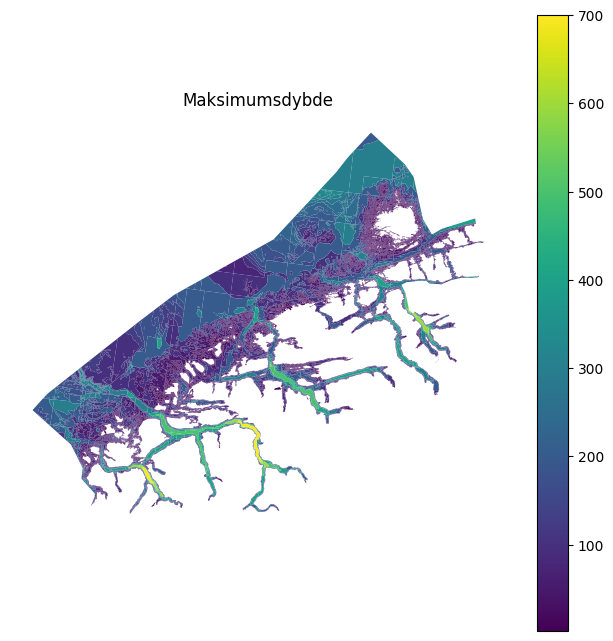

In [8]:
ax = gdf.plot(
    column="maksimumsdybde",
    cmap="viridis",
    legend=True,
    figsize=(8, 8),
    edgecolor="none"
)
ax.set_title("Maksimumsdybde")
ax.set_axis_off()

In [7]:
gdf_mr = gpd.read_parquet("../geonorge/Basisdata_15_More_og_Romsdal_25833_Dybdedata_Dybdekurve.geo.parquet")
gdf_vl = gpd.read_parquet("../geonorge/Basisdata_46_Vestland_25833_Dybdedata_Dybdekurve.geo.parquet")

gdf_vest = gpd.GeoDataFrame(pd.concat([gdf_mr, gdf_vl], ignore_index=True))

In [ ]:

from rasterio.fill import fillnodata
# Assuming 'gdf' is your existing GeoPandas DataFrame 
# 1. Wrap the GeoDataFrame in a GeoUtils Vector object
vector = gu.Vector(gdf_vest)

rasterized = vector.rasterize(
    xres=25.0,              # Spatial resolution in the units of your CRS (e.g., 10 meters)
    yres=25.0,
    crs=vector.crs,        # Use the CRS of your vector data
    bounds=vector.bounds,  # Use the bounding box of your vector data
    in_value=gdf_vest['dybde'],      # The GeoDataFrame column containing the values to burn
    out_value=-255      # Background (NoData) value for pixels outside the polygons
)
# 2. Extract the data array and create a mask of valid (non-NaN) pixels
data_array = rasterized.data[0] 
valid_mask = ~np.isnan(data_array)
dem = xdem.DEM(rasterized)


/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/interface/raster_vector.py:157: UserWarning: Bounds not a multiple of xres/yres, use rounded bounds.
  warnings.warn("Bounds not a multiple of xres/yres, use rounded bounds.")


AttributeError: 'DEM' object has no attribute 'interpolate'

In [ ]:
dem.plot()

In [6]:
dem.save("dybde_dem_25m.tif")

/tmp/ipykernel_17879/2777430516.py:1: DeprecationWarning: Call to deprecated function 'save'. The function .save() will be soon deprecated, use .to_file() instead. This functionality will be removed in version 0.3.0.
  dem.save("dybde_dem_25m.tif")


In [5]:

#dem = xdem.DEM(rio.open("../DEM25Norge_west_norway.tif"))

out_shape = dem.data.shape[-2:]  # loads DEM if not loaded
transform = dem.transform


### Marine vanntyper features



In [7]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(dem.crs)

In [8]:
marine_vanntyper_raster = subkart.features.rasterize_marine_types(marine_vanntyper, dem)

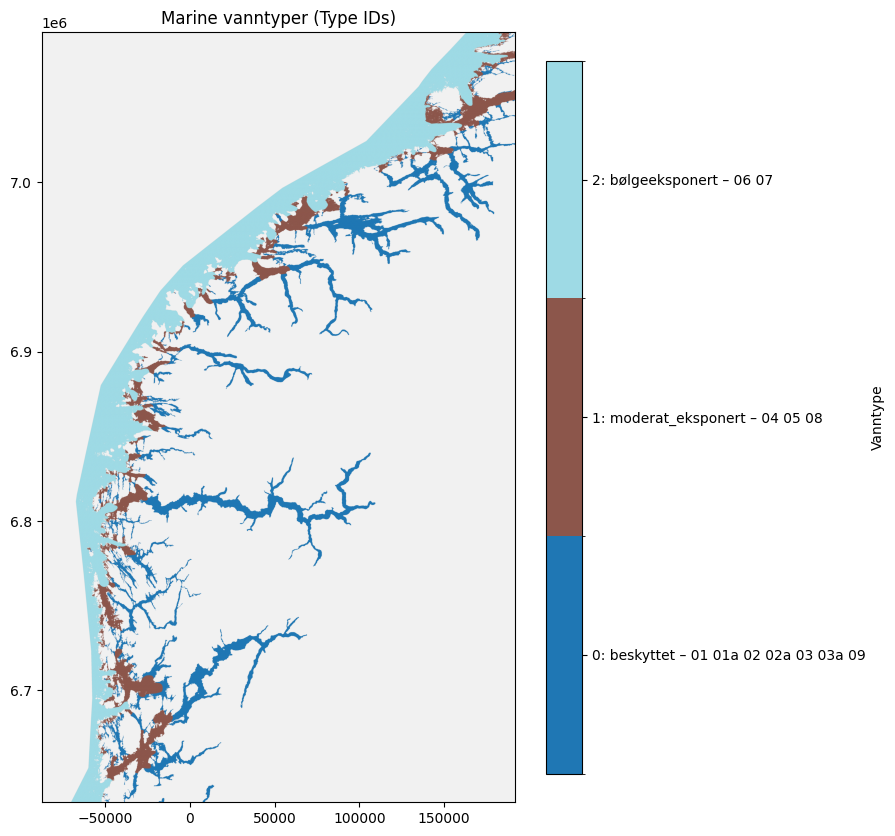

In [9]:

subkart.utils.plot_vanntyper(marine_vanntyper_raster, transform)


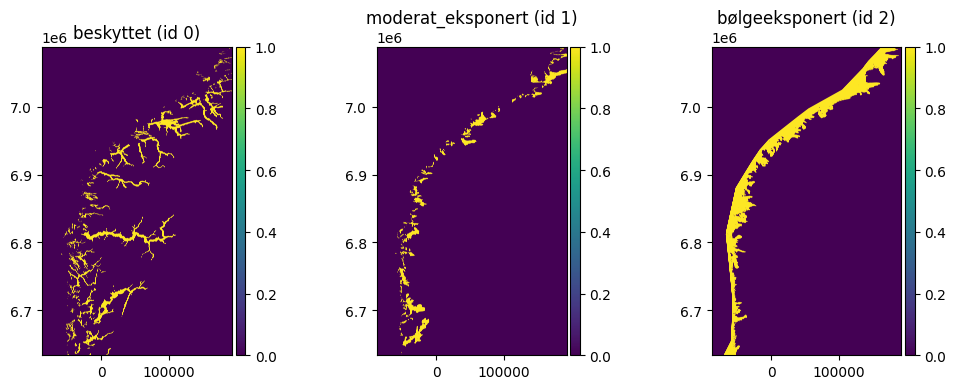

In [10]:

one_hot_types = subkart.features.one_hot_encode_marine_types(marine_vanntyper_raster)
subkart.utils.plot_one_hot_vanntyper(one_hot_types, transform, dem.crs, cols=3, rows=1)



## Dataset for labels

Using NGU bunnsedimenter detaljert

In [11]:
gdf_bunn_full = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet").to_crs(dem.crs)
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

['blanding/uspesifisert', 'fastbunn', 'løsbunn']

In [12]:

X, valid_attrs = subkart.features.build(dem, marine_vanntyper)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, out_shape, transform)
valid = valid_attrs & valid_bunn
X = X[valid]
y = bunn_raster[valid].astype(np.uint8)  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Training

## Baseline

Train a quick baseline for each model

In [13]:
# Ensure each model type is evaluated at least once before randomized search
baseline_models = [
    HistGradientBoostingClassifier(random_state=42),
    #RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
    #LogisticRegression(max_iter=100000, class_weight=class_weights, random_state=42),
]
score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - "
            f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline HistGradientBoostingClassifier - Train: 0.8019, Val: 0.7972


## Random Search

Search through hyperparameters for each model, this can take some time

In [ ]:

search_spaces = [
    {
        "model": [RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42)],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [10, 20],
        "model__min_samples_leaf": [4, 10],
        "model__min_samples_split": [5, 10],
        "model__max_features": ["sqrt", 0.5],
    },
    {
        "model": [HistGradientBoostingClassifier(random_state=42)],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__max_depth": [None, 6, 12],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__min_samples_leaf": [20, 50, 100],
        "model__l2_regularization": [0.0, 0.1, 1.0],
        "model__max_bins": [128, 255],
    },
    {
        "model": [LogisticRegression(max_iter=100000, class_weight=class_weights, random_state=42)],
        "model__C": [0.1, 1.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
]
pipe = Pipeline([("model", RandomForestClassifier())])
random_search = RandomizedSearchCV(
    pipe, param_distributions=search_spaces, n_iter=80, cv=2, verbose=3, random_state=42
)
random_search.fit(X_train, y_train)

# Use the best model for downstream cells
classifier = random_search.best_estimator_.named_steps["model"]

cv = random_search.cv_results_
best_by_model = {}

for i, p in enumerate(cv["params"]):
    model_name = type(p["model"]).__name__
    score = float(cv["mean_test_score"][i])
    if (model_name not in best_by_model) or (score > best_by_model[model_name]["score"]):
        readable = {}
        for k, v in p.items():
            if k == "model":
                continue
            readable[k.split("__", 1)[1] if k.startswith("model__") else k] = v
        best_by_model[model_name] = {"score": score, "params": readable}

# Print summary
for name, info in best_by_model.items():
    print(f"{name}: mean_test_score={info['score']:.4f}, params={info['params']}")

# Dump summary to JSON
with open("../data_generated/cv_best_by_model.json", "w", encoding="utf-8") as f:
    json.dump(
        {name: {"score": info["score"], "params": info["params"]} for name, info in best_by_model.items()},
        f,
        indent=2
    )

classifier.fit(X_train, y_train)
print("Train accuracy:", classifier.score(X_train, y_train))
print("Validation accuracy:", classifier.score(X_val, y_val))

Baseline RandomForestClassifier - Train: 0.9956, Val: 0.6835


Baseline HistGradientBoostingClassifier - Train: 0.6637, Val: 0.6631


Baseline LogisticRegression - Train: 0.5239, Val: 0.5240
Fitting 2 folds for each of 80 candidates, totalling 160 fits


[CV 1/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=1.0, model__learning_rate=0.2, model__max_bins=128, model__max_depth=6, model__max_leaf_nodes=63, model__min_samples_leaf=20;, score=0.662 total time=  48.5s


[CV 2/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=1.0, model__learning_rate=0.2, model__max_bins=128, model__max_depth=6, model__max_leaf_nodes=63, model__min_samples_leaf=20;, score=0.662 total time=  48.2s


...

[CV 1/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=0.0, model__learning_rate=0.05, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=127, model__min_samples_leaf=50;, score=0.668 total time= 1.1min


[CV 2/2] END model=HistGradientBoostingClassifier(random_state=42), model__l2_regularization=0.0, model__learning_rate=0.05, model__max_bins=255, model__max_depth=None, model__max_leaf_nodes=127, model__min_samples_leaf=50;, score=0.667 total time= 1.1min


HistGradientBoostingClassifier: mean_test_score=0.6715, params={'min_samples_leaf': 100, 'max_leaf_nodes': 127, 'max_depth': None, 'max_bins': 255, 'learning_rate': 0.2, 'l2_regularization': 0.1}
RandomForestClassifier: mean_test_score=0.6271, params={'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 20}


Train accuracy: 0.6759624354371259


Validation accuracy: 0.6725146046837218


In [14]:
dump(classifier, "../data_generated/classifier.joblib")

['../data_generated/classifier.joblib']

curvature: mean=0.077308, std=0.002335
depth: mean=0.005093, std=0.001315
slope: mean=0.004376, std=0.001128
vanntype_bølgeeksponert: mean=0.002200, std=0.000569
aspect: mean=0.000646, std=0.000802
vanntype_moderat_eksponert: mean=0.000574, std=0.000232
vanntype_beskyttet: mean=0.000215, std=0.000381


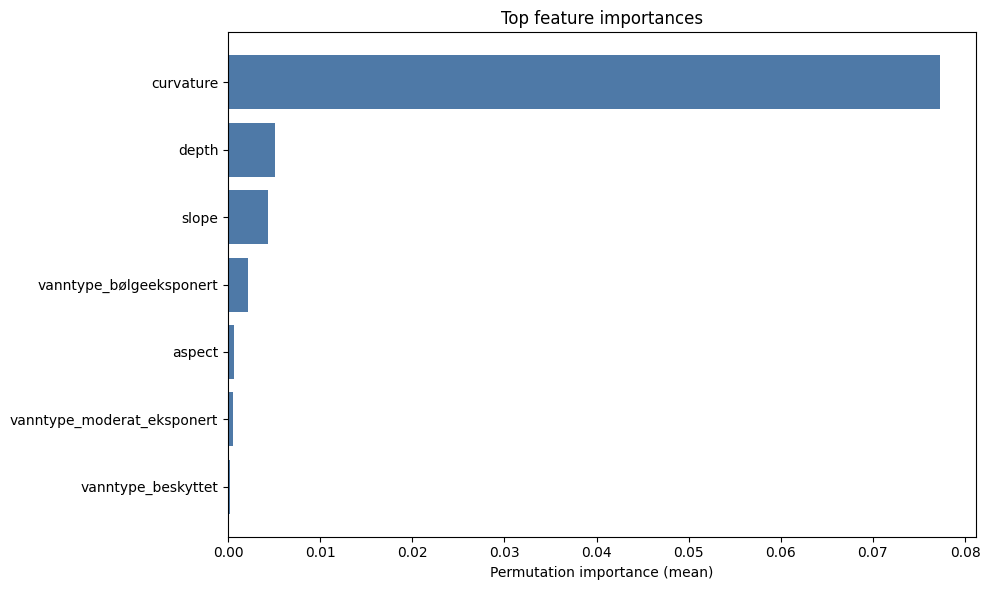

In [15]:
# Compute permutation importance for the best model on validation data
result = permutation_importance(
    classifier, X_val, y_val, n_repeats=5, random_state=42, n_jobs=2
)
_, id_type_map, _ = subkart.features.marine_type_map()
# Build feature names: terrain features + one-hot marine type features
terrain_features = ["depth", "slope", "aspect", "curvature"]
vanntype_names = list(id_type_map.values())
feature_names = terrain_features + [f"vanntype_{name}" for name in vanntype_names]

# Sort features by importance
importances_mean = result.importances_mean
importances_std = result.importances_std
sorted_idx = np.argsort(importances_mean)[::-1]

# Print top 20 features
top_n = 20
for i in sorted_idx[:top_n]:
    print(f"{feature_names[i]}: mean={importances_mean[i]:.6f}, std={importances_std[i]:.6f}")

# Save full importance results to JSON
importance_dict = [
    {
        "feature": feature_names[i],
        "mean": float(importances_mean[i]),
        "std": float(importances_std[i]),
    }
    for i in sorted_idx
]


top_idx = sorted_idx[:top_n]
labels = [feature_names[i] for i in top_idx]
values = importances_mean[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color="#4e79a7")
plt.xlabel("Permutation importance (mean)")
plt.title("Top feature importances")
plt.tight_layout()
plt.show()
